In [65]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ----------------------------- LOADING AND CLEANING DATA -------------------------------------------

# 1. Assign the id number to a variable for easier filtering for Nadal
nadal_id = "104745"

# Column Indices For Filtering. 
idx_name = 1
idx_surface = 2
idx_date = 5
idx_winner = 7
idx_loser = 17
idx_loser_rank = 25
idx_score = 27
idx_round = 29
idx_minutes = 30

#Lists to Store CSV Data
matches_2005 = []
matches_2008 = []

# Load 2005 Data into List
for line in open("atp_matches_2005.csv"):
    row = line.strip().split(",")
    if len(row) > 30 and row[0] != "tourney_id":
        if row[idx_surface] == "Clay":
            if row[idx_winner] == nadal_id or row[idx_loser] == nadal_id:
                matches_2005.append(row)

# Load 2008 Data into List
for line in open("atp_matches_2008.csv"):
    row = line.strip().split(",")
    if len(row) > 30 and row[0] != "tourney_id":
        if row[idx_surface] == "Clay":
            if row[idx_winner] == nadal_id or row[idx_loser] == nadal_id:
                matches_2008.append(row)

# Sort Matches by Date to make it easier to track win streaks.
def sort_matches(match_list):
    helper = []
    for row in match_list:
        # Create [date, row] pair
        helper.append([row[idx_date], row])
    helper.sort()
    
    # Extract sorted rows
    sorted_list = []
    for item in helper:
        sorted_list.append(item[1])
    return sorted_list

sorted_matches_2005 = sort_matches(matches_2005)
sorted_matches_2008 = sort_matches(matches_2008)

In [66]:
# ----------------------------- ANALYSIS OF DATA -------------------------------------------

# Analysis Function
def analyze_season(match_list):
    wins = 0
    losses = 0
    titles = 0
    rank_sum = 0
    rank_count = 0
    total_minutes = 0
    matches_count = 0
    total_sets_lost = 0 #not used 
    won_tournaments = []
    current_streak = 0
    max_streak = 0
    
    for row in match_list:
        winner = row[idx_winner]
        score_str = row[idx_score]
        time_str = row[idx_minutes]
        
        # Duration
        if time_str.isdigit():
            total_minutes += int(time_str)
            matches_count += 1

        # Stats
        if winner == nadal_id:
            wins += 1
            current_streak += 1
            if row[idx_round] == "F":
                if row[idx_name] not in won_tournaments:
                    titles += 1
                    won_tournaments.append(row[idx_name])
            if row[idx_loser_rank] != "":
                rank_sum += float(row[idx_loser_rank]) #convert to float for avergae calculation
                rank_count += 1
        else:
            losses += 1
            if current_streak > max_streak: 
                max_streak = current_streak
            current_streak = 0

    if current_streak > max_streak: 
        max_streak = current_streak
        
    avg_rank = rank_sum / rank_count 
    avg_duration = total_minutes / matches_count 
    matches = wins + losses
    
# creating dictionary to store all the results being processed
    results = {
        "Wins": wins, "Losses": losses, "Titles": titles,
        "Avg Opponent Rank": avg_rank, "Avg Duration(mins)": int(avg_duration),
        "Max Streak": max_streak, "Total Matches Played": matches
    }
    
    # --- PRINT STATEMENTS TO VERIFY NUMBERS ---
    print(f"--- Stats Verification --- 2005 first then 2008 ")
    for key, value in results.items(): # the ' , ' splits data in the dictionary
        print(f"{key}: {value}")
    
    print("\n")
    return results

# Test the Results of the Analysis
results_2005 = analyze_season(sorted_matches_2005)
results_2008 = analyze_season(sorted_matches_2008)

--- Stats Verification --- 2005 first then 2008 
Wins: 50
Losses: 2
Titles: 8
Avg Opponent Rank: 53.5
Avg Duration(mins): 108
Max Streak: 36
Total Matches Played: 52


--- Stats Verification --- 2005 first then 2008 
Wins: 24
Losses: 1
Titles: 4
Avg Opponent Rank: 29.875
Avg Duration(mins): 112
Max Streak: 14
Total Matches Played: 25




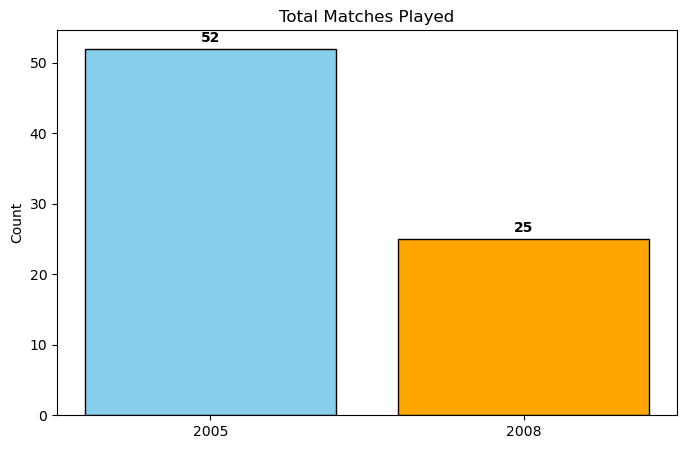

In [67]:
# CHARTS AND VISUALISATIONS


years = ['2005', '2008']
colors = ['skyblue', 'orange']

# --- CHART 1: TOTAL MATCHES PLAYED (Bar Chart) ---
plt.figure(figsize=(8, 5))
matches_data = [results_2005['Total Matches Played'], results_2008['Total Matches Played']]
plt.bar(years, matches_data, color=colors, edgecolor='black')
plt.title('Total Matches Played')
plt.ylabel('Count')
# Add labels
for i, v in enumerate(matches_data):
    plt.text(i, v + 1, str(v), ha='center', fontweight='bold')
plt.show()

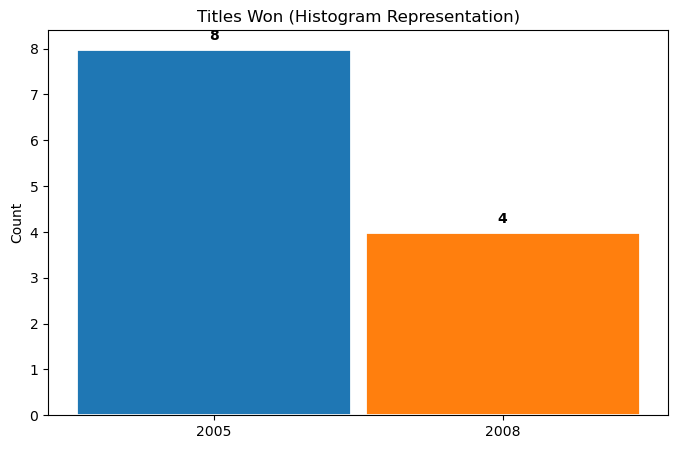

In [68]:
# --- CHART 2: TITLES WON (Histogram Representation) ---
# Using a Bar Chart with width=0.95 to look like a Histogram
plt.figure(figsize=(8, 5))
titles = [results_2005['Titles'], results_2008['Titles']]
plt.bar(years, titles, width=0.95, color=['#1f77b4', '#ff7f0e'], edgecolor='white', linewidth=2)
plt.title('Titles Won (Histogram Representation)')
plt.ylabel('Count')
for i, v in enumerate(titles):
    plt.text(i, v + 0.2, str(v), ha='center', color='black', fontweight='bold')
plt.show()

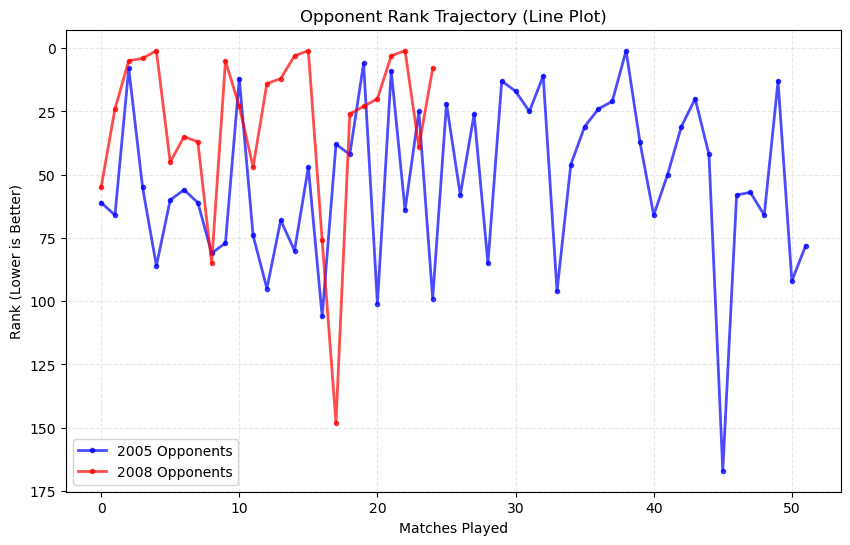

In [69]:
# --- CHART 3: ALL OPPONENT RANKS (Line Plot) ---
plt.figure(figsize=(10, 6))
plt.plot(ranks_2005, label='2005 Opponents', color='blue', linewidth=2, marker='.', alpha=0.7)
plt.plot(ranks_2008, label='2008 Opponents', color='red', linewidth=2, marker='.', alpha=0.7)
plt.title('Opponent Rank Trajectory (Line Plot)')
plt.ylabel('Rank (Lower is Better)')
plt.xlabel('Matches Played')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.gca().invert_yaxis() # Puts Rank 1 at the top
plt.show()

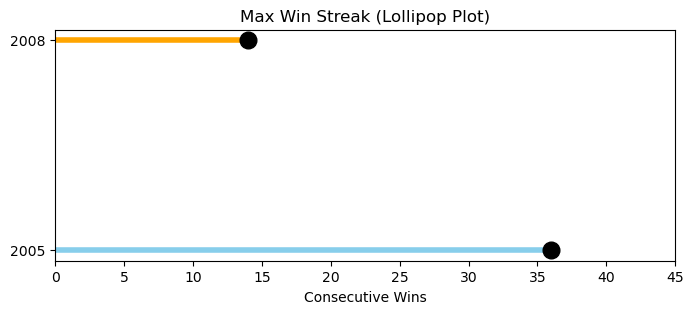

In [70]:
# --- CHART 4: LONGEST STREAK (Lollipop Plot) ---
plt.figure(figsize=(8, 3))
streaks = [results_2005['Max Streak'], results_2008['Max Streak']]
plt.hlines(y=years, xmin=0, xmax=streaks, color=colors, linewidth=4)
plt.plot(streaks, years, 'o', color='black', markersize=12)
plt.title('Max Win Streak (Lollipop Plot)')
plt.xlabel('Consecutive Wins')
plt.xlim(0, 45)
plt.show()

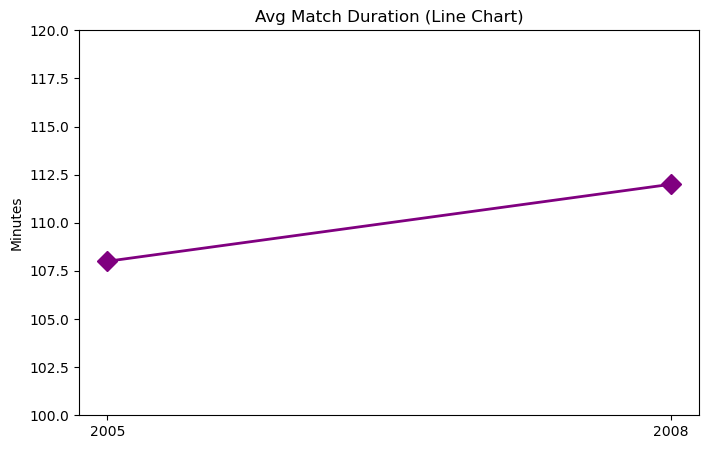

In [71]:
# --- CHART 5: AVERAGE DURATION (Line Chart) ---
plt.figure(figsize=(8, 5))
durations = [results_2005['Avg Duration(mins)'], results_2008['Avg Duration(mins)']]
plt.plot(years, durations, marker='D', linestyle='-', color='purple', markersize=10, linewidth=2)
plt.title('Avg Match Duration (Line Chart)')
plt.ylabel('Minutes')
plt.ylim(100, 120)
plt.show()

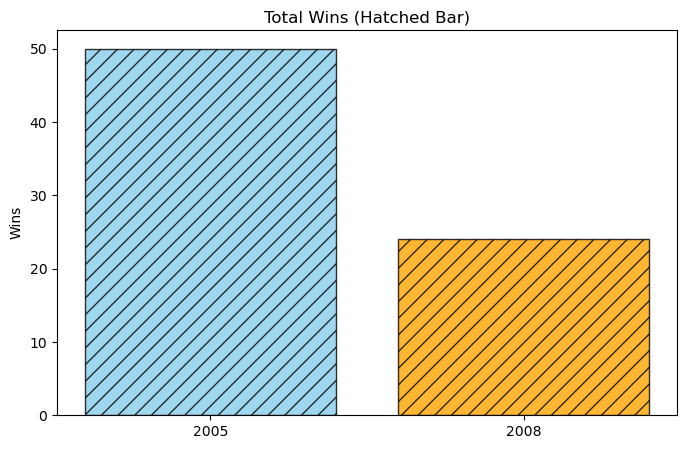

In [72]:
# --- CHART 6: WINS COMPARISON (Hatched Bar Chart) ---
plt.figure(figsize=(8, 5))
wins_data = [results_2005['Wins'], results_2008['Wins']]
plt.bar(years, wins_data, color=colors, alpha=0.8, hatch='//', edgecolor='black')
plt.title('Total Wins (Hatched Bar)')
plt.ylabel('Wins')
plt.show()